In [84]:
import json
import os
import yaml
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from umap.umap_ import UMAP
import seaborn as sns
from datasets import load_dataset, Dataset
from huggingface_hub import login

In [29]:
with open('../configs/generation_config.yaml', 'r') as file:
    generation_config = yaml.safe_load(file)
        
with open('../psychometric_tests/hexaco_100_eval.yaml', 'r') as file:
    hexaco_eval = yaml.safe_load(file)

In [30]:
def load_personas(hf_persona_path,n_personasample):
    
    print("Using Huggingface Personas")
    print(f"Loading Personas from {hf_persona_path}")
    hf_persona_dataset = load_dataset(hf_persona_path)
    persona_datasets_total = hf_persona_dataset['train']
    total_persona_df = persona_datasets_total.to_pandas()
    persona_datasets = total_persona_df.groupby("archetype").sample(n=n_personasample, random_state=42)
    print(f"No of Personas: {persona_datasets.shape[0]}")
    return persona_datasets

In [31]:
def write_to_json(file, file_path):
    os.makedirs(os.path.dirname(file_path), exist_ok=True)
    with open(file_path, 'w') as f:
        json.dump(file, f, indent=2)


def read_json(file_path):
    with open(file_path, "r") as f:
        return json.load(f)
    
def get_model_name(filename, file_str):
    model_name = filename.replace("_hexaco_answers_","").replace(".json","").replace(file_str,"")
    return model_name

In [32]:
def calculate_hexaco_score(trait, subtrait, answers, likert_scale = generation_config['likert_scale']):
    # answer_dict = {}
    answers = [answer if answer in likert_scale else "Do not wish to answer" for answer in answers]
    answers = pd.Series(answers)
    subtrait_dict = hexaco_eval[trait][subtrait]
    indices = [idx - 1 for idx in subtrait_dict['indices']]
    trait_answers = answers[indices]
    refused_answers = trait_answers[trait_answers.isin(['Do not wish to answer','Do not wish to answer.'])]
    non_refused_answers = trait_answers[~trait_answers.isin(['Do not wish to answer','Do not wish to answer.'])]
    answer_indices = [likert_scale.index(answer) + 1 for answer in non_refused_answers]
    # print(answer_indices)
    true_answer_indices = [6-idx if reverse else idx for idx,reverse in zip(answer_indices, subtrait_dict['reverse'])]
    
    # answer_dict['answer_indices'] = answer_indices
    # answer_dict['true_answer_indices'] = true_answer_indices
    # answer_dict['n_answered_questions'] = len(true_answer_indices)
    # answer_dict['n_refused_questions'] = len(refused_answers)
    # answer_dict['trait'] = trait
    # answer_dict['subtrait'] = subtrait
    # answer_dict['subtrait_score'] = np.round(np.mean(true_answer_indices).item(),3)
    return true_answer_indices

def get_trait_scores(answer,likert_scale = generation_config['likert_scale']):
    trait_score = []
    for trait in hexaco_eval.keys():
        for subtrait in hexaco_eval[trait].keys():
            trait_true_answer_indices = []
            trait_true_answer_indices.extend(calculate_hexaco_score(trait, subtrait, answer, likert_scale))
        
        trait_score.append(np.round(np.mean(trait_true_answer_indices).item(),3).item())
    return trait_score

In [14]:
zero_compute_data_dir = "../experiment_results/zero_compute_analysis_hexaco/"

In [33]:
hexaco_mapping = {"Strongly Disagree": -2, "Disagree": -1, "Neutral": 0, "Agree": 1, "Strongly Agree":2, "Do not wish to answer": -3}
trait_list = ['honest-humility','emotionality','extraversion','agreeableness','conscientiousness','openness to experience','altruism']

huggingface_hexaco_answers_Qwen2_5-7B-Instruct.json


/var/folders/9b/k67tngbx13jgzw5kjx9_d0tc0000gn/T/ipykernel_67478/1822530561.py:12: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  persona_hexaco_df = persona_hexaco_str_answers_df.replace(hexaco_mapping)
/Users/shreyansjain/.pyenv/versions/3.11.9/envs/llm_psychometrics/lib/python3.11/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


huggingface_hexaco_answers_gpt-4_1.json


/var/folders/9b/k67tngbx13jgzw5kjx9_d0tc0000gn/T/ipykernel_67478/1822530561.py:12: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  persona_hexaco_df = persona_hexaco_str_answers_df.replace(hexaco_mapping)
/Users/shreyansjain/.pyenv/versions/3.11.9/envs/llm_psychometrics/lib/python3.11/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


huggingface_hexaco_answers_Llama-3_1-8B-Instruct.json


/var/folders/9b/k67tngbx13jgzw5kjx9_d0tc0000gn/T/ipykernel_67478/1822530561.py:12: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  persona_hexaco_df = persona_hexaco_str_answers_df.replace(hexaco_mapping)
/Users/shreyansjain/.pyenv/versions/3.11.9/envs/llm_psychometrics/lib/python3.11/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


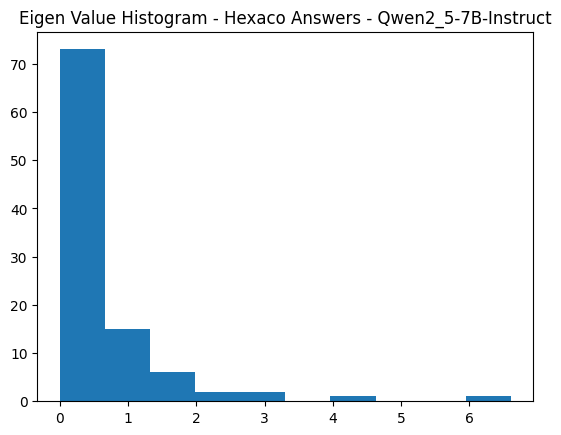

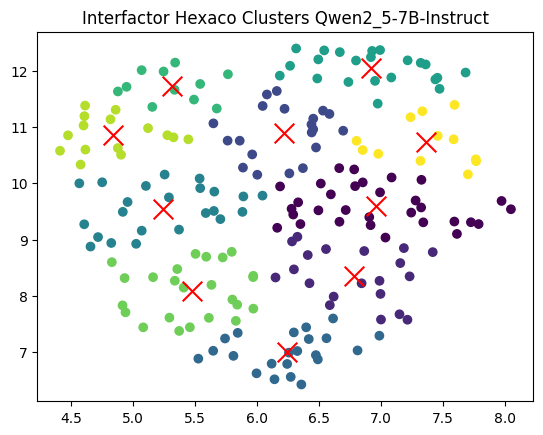

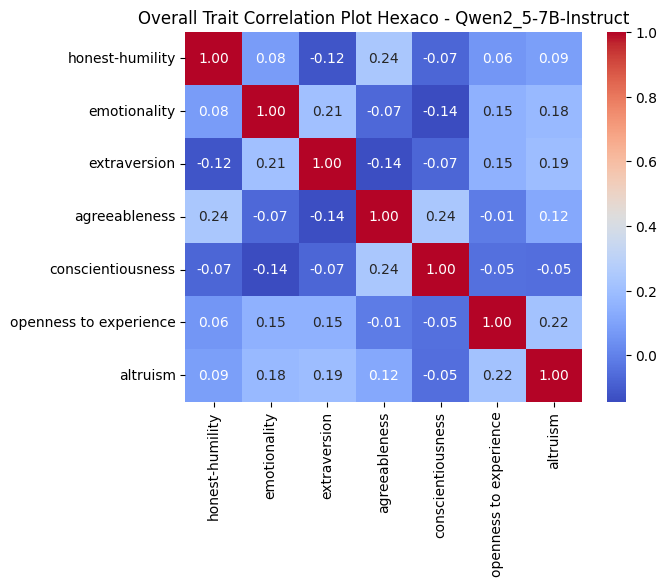

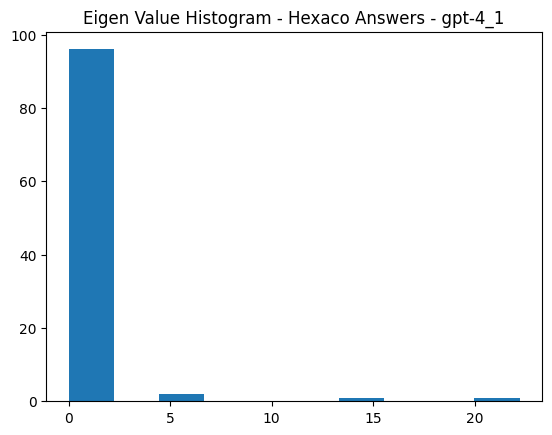

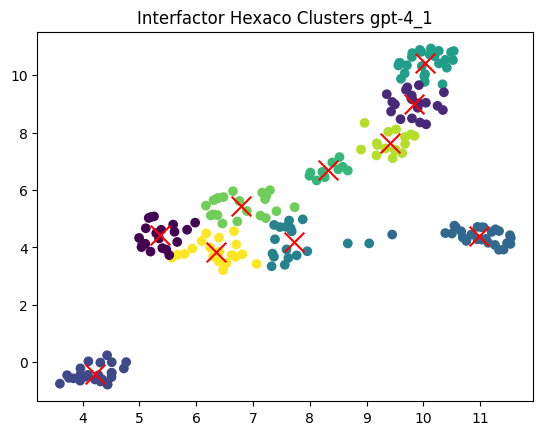

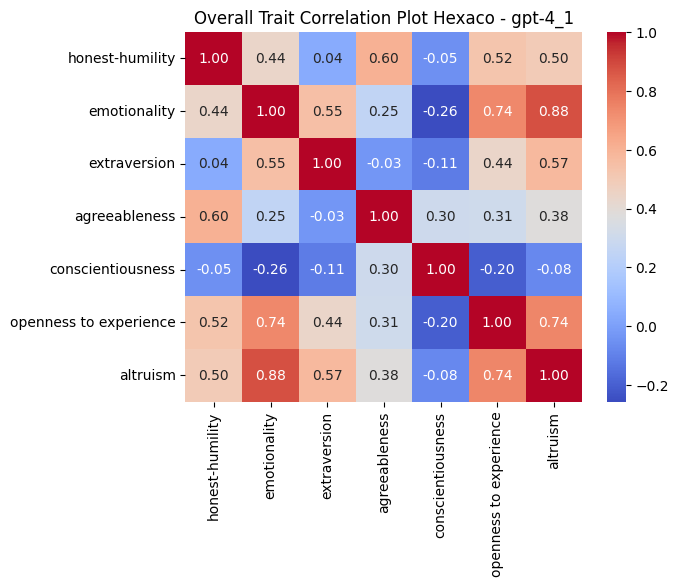

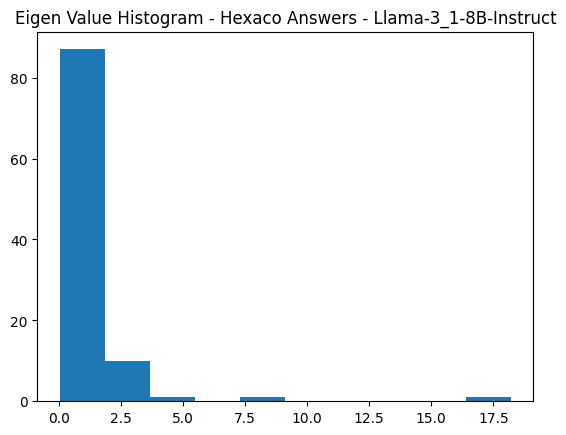

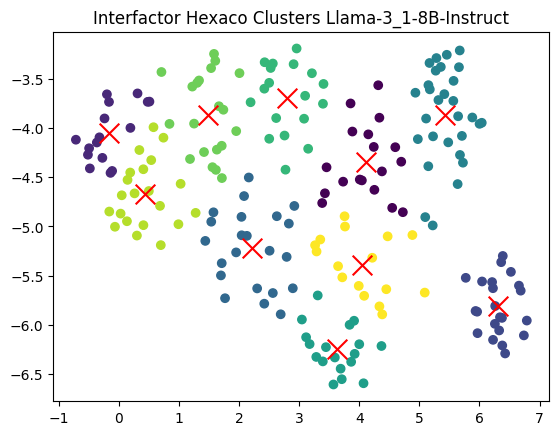

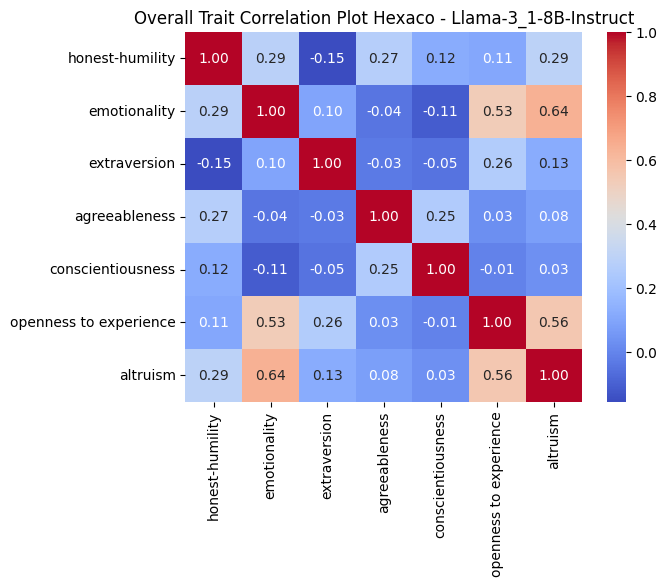

In [122]:
file_str = "huggingface"
# hf_hexaco_trait_persona_df = pd.DataFrame()
for filename in os.listdir(zero_compute_data_dir):
    if ".json" in filename:
        print(filename)
        
        model_name = get_model_name(filename, file_str)
        hf_persona_hexaco_results = read_json(os.path.join(zero_compute_data_dir, filename))
        persona_hexaco_str_answers_df = pd.DataFrame([{"persona_id": key, "answers": hf_persona_hexaco_results[key]['answers'][0]} for key in hf_persona_hexaco_results.keys()])

        persona_hexaco_str_answers_df = pd.DataFrame(persona_hexaco_str_answers_df['answers'].to_list(), columns = list(range(0,100)), index = persona_hexaco_str_answers_df['persona_id'])
        persona_hexaco_df = persona_hexaco_str_answers_df.replace(hexaco_mapping)
        
        plt.figure()
        plt.hist(np.linalg.eigvals(np.cov(persona_hexaco_df.values.T)))
        plt.title(f"Eigen Value Histogram - Hexaco Answers - {model_name}")
        plt.savefig(os.path.join(zero_compute_data_dir,  "analysis_results",f"Eigen_histogram_hexaco_{model_name}"), dpi=300)
        
        umap_model = UMAP(n_components=2, n_neighbors=15, min_dist=0.1, random_state=42)
        X_reduced = umap_model.fit_transform(persona_hexaco_df)
        
        kmeans_model = KMeans(n_clusters=10, random_state=42)
        kmeans_model.fit(X_reduced)
        
        labels = kmeans_model.labels_
        centroids = kmeans_model.cluster_centers_

        plt.figure()
        plt.scatter(X_reduced[:, 0], X_reduced[:, 1], c=labels, cmap='viridis', marker='o')
        plt.scatter(centroids[:, 0], centroids[:, 1], c='red', marker='x', s=200)
        plt.title(f"Interfactor Hexaco Clusters {model_name}")
        plt.savefig(os.path.join(zero_compute_data_dir, "analysis_results",f"interfactor_clusters_hexaco_{model_name}"), dpi=300)
        
        hexaco_trait_persona_df = pd.DataFrame(persona_hexaco_str_answers_df.apply(lambda x: get_trait_scores(x),axis = 1).to_list(), index = persona_hexaco_str_answers_df.index, columns = trait_list)

        # hexaco_trait_persona_df['cluster_labels'] = labels
        # hexaco_trait_persona_df['model_name'] = model_name
        # hf_hexaco_trait_persona_df = pd.concat([hf_hexaco_trait_persona_df,hexaco_trait_persona_df],axis = 0)
        
        
        plt.figure()
        sns.heatmap(np.corrcoef(hexaco_trait_persona_df.T - 3),annot=True, cmap="coolwarm", fmt=".2f", cbar=True,xticklabels=hexaco_trait_persona_df.columns,yticklabels=hexaco_trait_persona_df.columns)
        plt.title(f"Overall Trait Correlation Plot Hexaco - {model_name}")
        plt.savefig(os.path.join(zero_compute_data_dir, "analysis_results",f"trait_correlation_hexaco_{model_name}"),
                    bbox_inches='tight', dpi=300)

In [128]:
hexaco_trait_persona_df

,honest-humility,emotionality,extraversion,agreeableness,conscientiousness,openness to experience,altruism,model_name
persona_id,,,,,,,,
782f13f4-0d98-41b4-a170-a2839dc6be70,3.50,3.75,1.50,3.75,3.50,3.25,4.25,Llama-3_1-8B-Instruct
81596279-9ae8-463f-bb93-f8f0f88d777e,3.50,2.00,2.00,3.50,3.75,2.75,3.50,Llama-3_1-8B-Instruct
6ce72d58-d03e-46d3-ae63-28b1bad56c26,3.25,2.75,1.50,3.75,3.75,2.75,2.50,Llama-3_1-8B-Instruct
e960e68a-f260-48df-8cb7-d6f8a46e470a,3.50,3.00,2.00,3.25,3.00,2.75,3.25,Llama-3_1-8B-Instruct
e3d265c4-b172-44f0-b058-be4d42fe5fb4,3.25,2.25,1.50,2.75,3.50,2.75,3.50,Llama-3_1-8B-Instruct
...,...,...,...,...,...,...,...,...
197a10f3-35a9-4fda-8245-6a02c2980762,2.50,1.25,1.75,3.50,3.25,2.75,4.00,Llama-3_1-8B-Instruct
d1403dfc-c79b-4eb8-b017-372942ff3930,3.25,3.25,3.25,2.75,3.25,3.50,4.50,Llama-3_1-8B-Instruct
07406572-896a-42fe-bbc1-126104622bf7,3.00,1.75,3.25,3.00,3.75,3.25,3.50,Llama-3_1-8B-Instruct


In [123]:
for filename in os.listdir(zero_compute_data_dir):
    if ".json" in filename:
        print(filename)

huggingface_hexaco_answers_Qwen2_5-7B-Instruct.json
huggingface_hexaco_answers_gpt-4_1.json
huggingface_hexaco_answers_Llama-3_1-8B-Instruct.json


In [124]:
file_str = "huggingface"
hf_hexaco_trait_persona_df = pd.DataFrame()
for filename in os.listdir(zero_compute_data_dir):
    if ".json" in filename:
        print(filename)
        
        model_name = get_model_name(filename, file_str)
        hf_persona_hexaco_results = read_json(os.path.join(zero_compute_data_dir, filename))
        persona_hexaco_str_answers_df = pd.DataFrame([{"persona_id": key, "answers": hf_persona_hexaco_results[key]['answers'][0]} for key in hf_persona_hexaco_results.keys()])

        persona_hexaco_str_answers_df = pd.DataFrame(persona_hexaco_str_answers_df['answers'].to_list(), columns = list(range(0,100)), index = persona_hexaco_str_answers_df['persona_id'])
        persona_hexaco_df = persona_hexaco_str_answers_df.replace(hexaco_mapping)
        
        
        hexaco_trait_persona_df = pd.DataFrame(persona_hexaco_str_answers_df.apply(lambda x: get_trait_scores(x),axis = 1).to_list(), index = persona_hexaco_str_answers_df.index, columns = trait_list)

        # hexaco_trait_persona_df['cluster_labels'] = labels
        hexaco_trait_persona_df['model_name'] = model_name
        print(hf_hexaco_trait_persona_df.shape)
        hf_hexaco_trait_persona_df = pd.concat([hf_hexaco_trait_persona_df,hexaco_trait_persona_df],axis = 0)
        print(hf_hexaco_trait_persona_df.shape)

huggingface_hexaco_answers_Qwen2_5-7B-Instruct.json


/var/folders/9b/k67tngbx13jgzw5kjx9_d0tc0000gn/T/ipykernel_67478/1816713311.py:12: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  persona_hexaco_df = persona_hexaco_str_answers_df.replace(hexaco_mapping)


(0, 0)
(200, 8)
huggingface_hexaco_answers_gpt-4_1.json


/var/folders/9b/k67tngbx13jgzw5kjx9_d0tc0000gn/T/ipykernel_67478/1816713311.py:12: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  persona_hexaco_df = persona_hexaco_str_answers_df.replace(hexaco_mapping)


(200, 8)
(400, 8)
huggingface_hexaco_answers_Llama-3_1-8B-Instruct.json


/var/folders/9b/k67tngbx13jgzw5kjx9_d0tc0000gn/T/ipykernel_67478/1816713311.py:12: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  persona_hexaco_df = persona_hexaco_str_answers_df.replace(hexaco_mapping)


(400, 8)
(600, 8)


hf_hexaco_trait_persona_df.reset_index().to_csv(os.path.join(zero_compute_data_dir, "hf_hexaco_trait_persona_df.csv"),index = False)

In [129]:
login("")
persona_datasets = load_personas("thoughtworks/psychometric_personas",25)

Using Huggingface Personas
Loading Personas from thoughtworks/psychometric_personas
No of Personas: 200


In [166]:
def hexaco_aggregation_by_attribute(hexaco_df, attribute):
        
    persona_df = persona_datasets[['uuid',attribute]].drop_duplicates()
    attribute_hexaco = pd.merge(hexaco_df, persona_df, left_on="persona_id", right_on="uuid", how = "inner")
    
    return attribute_hexaco.drop("uuid", axis = 1).groupby([attribute,'model_name'], as_index=False).mean()

def categorize_age(age):
    if pd.isna(age):
        return "unknown"
    elif age < 18:
        return "juvenile"
    elif 18 <= age < 25:
        return "young_adult"
    elif 25 <= age < 40:
        return "adult"
    elif 40 <= age < 60:
        return "middle_aged"
    else:
        return "senior"
    
def get_preferred_trait_df(attribute_df, attribute):
    
    attribute_df['preferred_trait'] = attribute_df[trait_list].idxmax(axis = 1)
    
    return attribute_df[[attribute,'model_name','preferred_trait']].pivot(index=attribute, columns='model_name', values='preferred_trait')
    

In [163]:
persona_datasets["age_category"] = persona_datasets["age"].apply(categorize_age)

## Hexaco Profile By Archetype

In [171]:
archetype_hexaco = hexaco_aggregation_by_attribute(hf_hexaco_trait_persona_df,attribute="archetype")
archetype_hexaco

,archetype,model_name,honest-humility,emotionality,extraversion,agreeableness,conscientiousness,openness to experience,altruism
0,The Avoider (Lazy Officer),Llama-3_1-8B-Instruct,3.36000,2.55000,2.29000,3.25000,3.39000,2.89000,3.38000
1,The Avoider (Lazy Officer),Qwen2_5-7B-Instruct,3.38672,3.54000,2.58668,3.39000,4.05668,3.08992,3.74668
2,The Avoider (Lazy Officer),gpt-4_1,4.02000,2.08000,1.84000,3.87000,4.21000,2.22000,3.28000
3,The Avoider (Unconfident Officer),Llama-3_1-8B-Instruct,3.44000,3.59000,2.40000,3.05000,3.29000,3.38000,3.98000
4,The Avoider (Unconfident Officer),Qwen2_5-7B-Instruct,3.57336,3.63336,2.56664,3.37332,4.05000,3.09664,4.02000
5,The Avoider (Unconfident Officer),gpt-4_1,4.24000,3.51000,2.04000,4.03000,4.47000,3.01000,4.28000
6,The Enforcer (Crime-Fighter),Llama-3_1-8B-Instruct,3.01000,3.34000,2.87000,2.93000,3.22000,3.57000,3.97000
7,The Enforcer (Crime-Fighter),Qwen2_5-7B-Instruct,3.30332,3.69332,3.28332,3.15668,4.12332,3.03664,3.89000
8,The Enforcer (Crime-Fighter),gpt-4_1,3.69000,2.69000,2.66000,2.94000,4.52000,2.42000,3.79000
9,The Problem Solver / Investigator,Llama-3_1-8B-Instruct,3.24000,2.81000,2.59000,3.19000,3.50000,3.50000,3.92000


In [167]:
get_preferred_trait_df(archetype_hexaco, "archetype")

model_name,Llama-3_1-8B-Instruct,Qwen2_5-7B-Instruct,gpt-4_1
archetype,,,
The Avoider (Lazy Officer),conscientiousness,conscientiousness,conscientiousness
The Avoider (Unconfident Officer),altruism,conscientiousness,conscientiousness
The Enforcer (Crime-Fighter),altruism,conscientiousness,conscientiousness
The Problem Solver / Investigator,altruism,conscientiousness,conscientiousness
The Problem Solver / Public Servant,altruism,altruism,altruism
The Professional (Service-Oriented Officer),altruism,conscientiousness,conscientiousness
The Reciprocator (Nice Cop),altruism,conscientiousness,altruism
The Tough Cop (Authoritarian),altruism,conscientiousness,conscientiousness


In [170]:
ethnic_hexaco = hexaco_aggregation_by_attribute(hf_hexaco_trait_persona_df,attribute="ethnic_background")
ethnic_hexaco

,ethnic_background,model_name,honest-humility,emotionality,extraversion,agreeableness,conscientiousness,openness to experience,altruism
0,black,Llama-3_1-8B-Instruct,3.347826,3.369565,2.684783,3.184783,3.597826,3.510870,4.239130
1,black,Qwen2_5-7B-Instruct,3.405826,3.641304,2.949261,3.529000,4.195652,3.134000,3.934783
2,black,gpt-4_1,4.065217,3.173913,2.728261,3.760870,4.739130,3.043478,4.119565
3,colombian,Llama-3_1-8B-Instruct,3.500000,2.250000,2.000000,3.750000,3.500000,3.000000,3.000000
4,colombian,Qwen2_5-7B-Instruct,3.000000,4.000000,2.750000,3.750000,3.000000,3.000000,3.500000
5,colombian,gpt-4_1,4.000000,2.000000,1.750000,4.250000,5.000000,2.000000,2.750000
6,cuban,Llama-3_1-8B-Instruct,3.000000,3.625000,2.500000,2.812500,3.500000,3.500000,4.312500
7,cuban,Qwen2_5-7B-Instruct,3.666750,3.875000,3.375000,3.125000,4.125000,3.208250,4.000000
8,cuban,gpt-4_1,3.625000,3.187500,3.000000,3.250000,4.187500,2.875000,4.000000
9,dominican,Llama-3_1-8B-Instruct,3.000000,4.500000,2.750000,3.250000,3.000000,4.000000,4.750000


In [168]:
get_preferred_trait_df(ethnic_hexaco, "ethnic_background")

model_name,Llama-3_1-8B-Instruct,Qwen2_5-7B-Instruct,gpt-4_1
ethnic_background,,,
black,altruism,conscientiousness,conscientiousness
colombian,agreeableness,emotionality,conscientiousness
cuban,altruism,conscientiousness,conscientiousness
dominican,altruism,emotionality,conscientiousness
east asian,altruism,conscientiousness,conscientiousness
ecuadorian,altruism,conscientiousness,altruism
guatemalan,altruism,altruism,conscientiousness
hispanic or latino other,altruism,conscientiousness,conscientiousness
honduran,altruism,conscientiousness,conscientiousness


In [169]:
age_category_hexaco = hexaco_aggregation_by_attribute(hf_hexaco_trait_persona_df,attribute="age_category")
get_preferred_trait_df(age_category_hexaco, "age_category")

model_name,Llama-3_1-8B-Instruct,Qwen2_5-7B-Instruct,gpt-4_1
age_category,,,
adult,altruism,conscientiousness,conscientiousness
middle_aged,altruism,conscientiousness,conscientiousness
senior,altruism,altruism,conscientiousness
young_adult,altruism,conscientiousness,conscientiousness


huggingface_hexaco_answers_Qwen2_5-7B-Instruct.json


/var/folders/9b/k67tngbx13jgzw5kjx9_d0tc0000gn/T/ipykernel_67478/3267840680.py:12: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  persona_hexaco_df = persona_hexaco_str_answers_df.replace(hexaco_mapping)
/Users/shreyansjain/.pyenv/versions/3.11.9/envs/llm_psychometrics/lib/python3.11/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


huggingface_hexaco_answers_gpt-4_1.json


/var/folders/9b/k67tngbx13jgzw5kjx9_d0tc0000gn/T/ipykernel_67478/3267840680.py:12: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  persona_hexaco_df = persona_hexaco_str_answers_df.replace(hexaco_mapping)
/Users/shreyansjain/.pyenv/versions/3.11.9/envs/llm_psychometrics/lib/python3.11/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


huggingface_hexaco_answers_Llama-3_1-8B-Instruct.json


/var/folders/9b/k67tngbx13jgzw5kjx9_d0tc0000gn/T/ipykernel_67478/3267840680.py:12: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  persona_hexaco_df = persona_hexaco_str_answers_df.replace(hexaco_mapping)
/Users/shreyansjain/.pyenv/versions/3.11.9/envs/llm_psychometrics/lib/python3.11/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


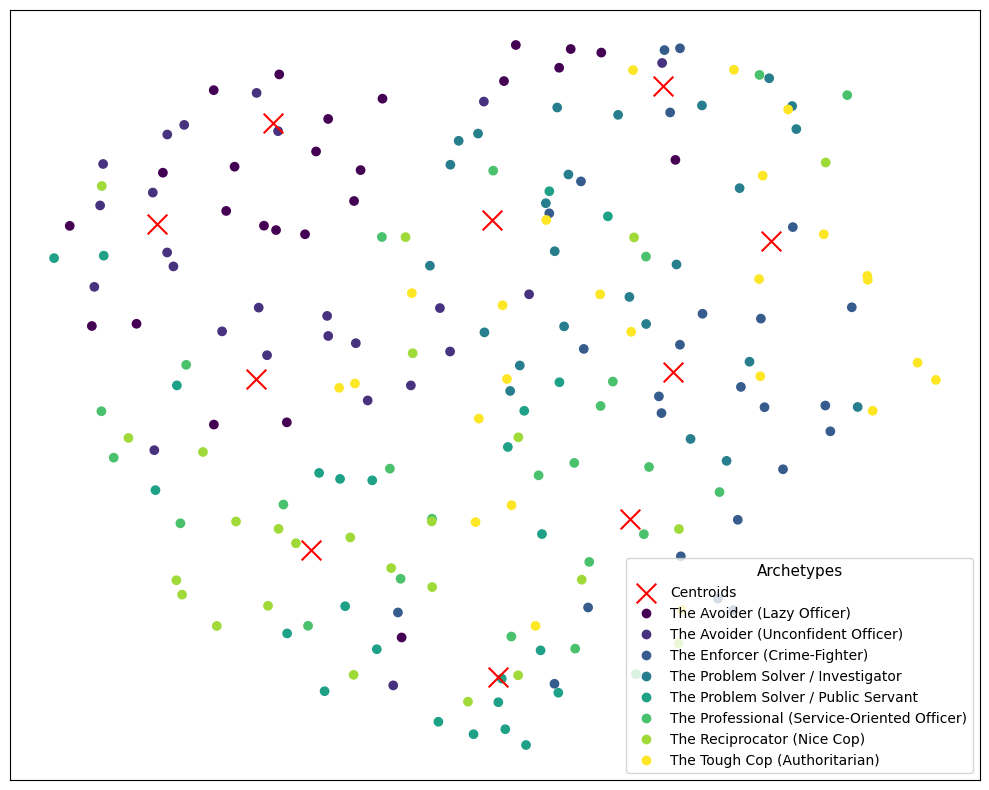

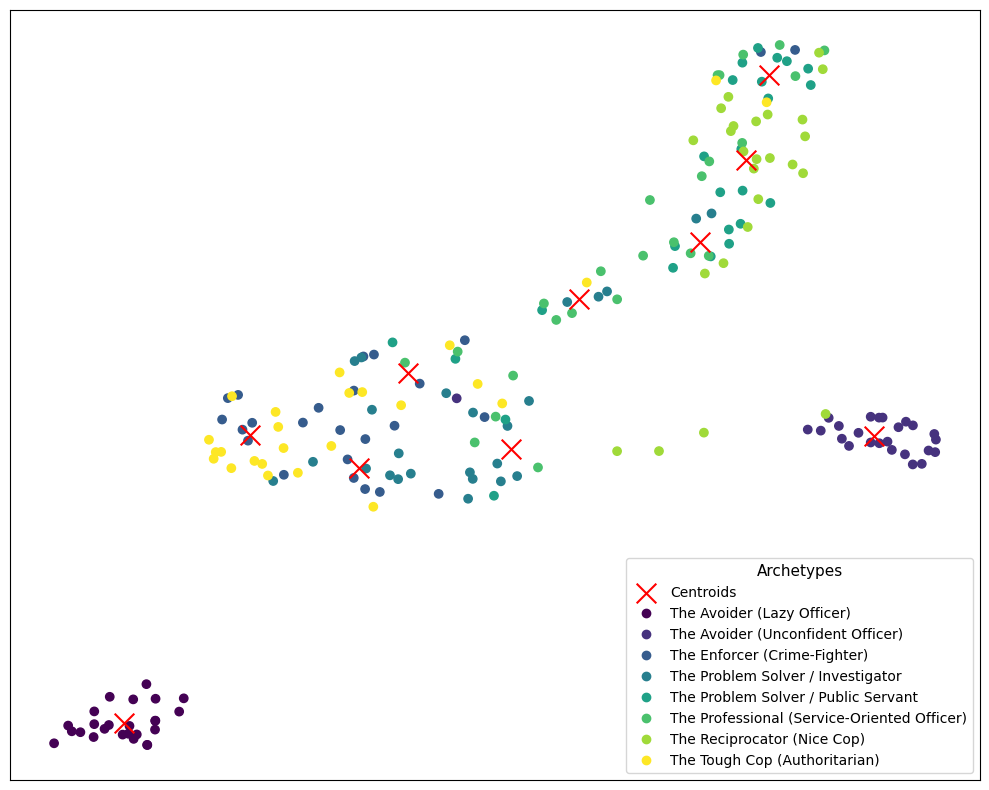

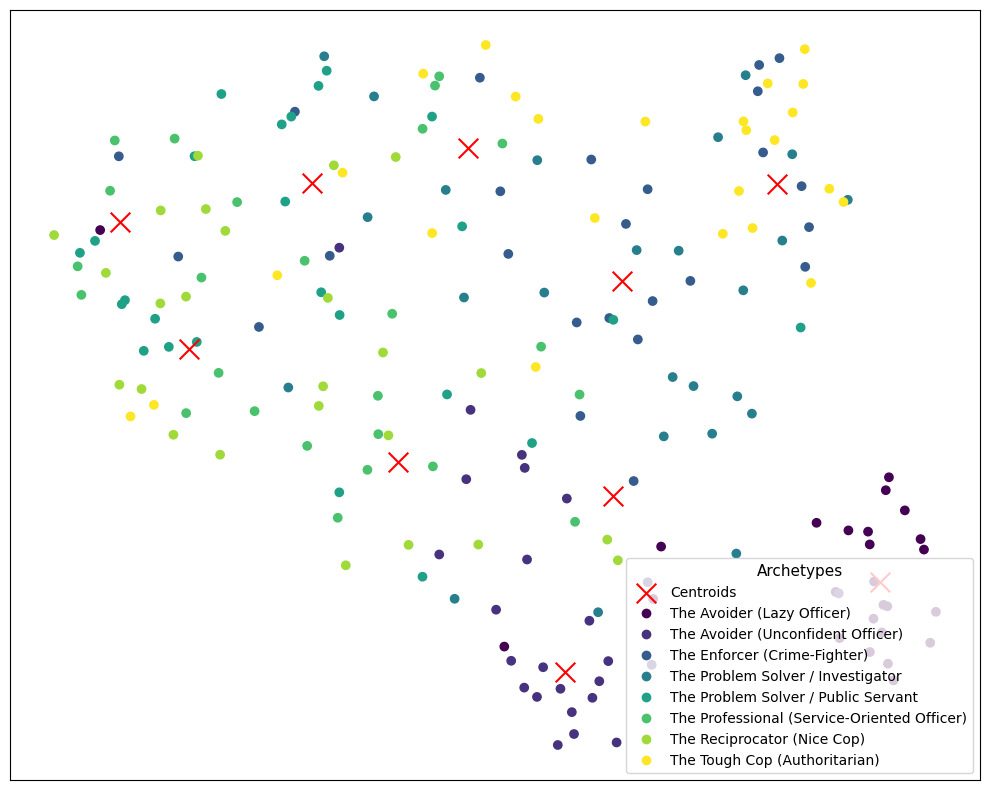

In [174]:
file_str = "huggingface"
# hf_hexaco_trait_persona_df = pd.DataFrame()
for filename in os.listdir(zero_compute_data_dir):
    if ".json" in filename:
        print(filename)
        
        model_name = get_model_name(filename, file_str)
        hf_persona_hexaco_results = read_json(os.path.join(zero_compute_data_dir, filename))
        persona_hexaco_str_answers_df = pd.DataFrame([{"persona_id": key, "answers": hf_persona_hexaco_results[key]['answers'][0]} for key in hf_persona_hexaco_results.keys()])

        persona_hexaco_str_answers_df = pd.DataFrame(persona_hexaco_str_answers_df['answers'].to_list(), columns = list(range(0,100)), index = persona_hexaco_str_answers_df['persona_id'])
        persona_hexaco_df = persona_hexaco_str_answers_df.replace(hexaco_mapping)
        
        umap_model = UMAP(n_components=2, n_neighbors=15, min_dist=0.1, random_state=42)
        X_reduced = umap_model.fit_transform(persona_hexaco_df)
        
        kmeans_model = KMeans(n_clusters=10, random_state=42)
        kmeans_model.fit(X_reduced)
        
        labels = kmeans_model.labels_
        centroids = kmeans_model.cluster_centers_
        
        archetype_labels = pd.merge(archetype_df, pd.Series(persona_hexaco_df.index), left_on = "uuid", how='inner', right_on="persona_id")['archetype']
        archetype_codes = archetype_labels.astype('category').cat.codes

        plt.figure(figsize=(10, 8))
        ax = plt.gca()

        # Plot archetypes
        scatter = ax.scatter(X_reduced[:, 0], X_reduced[:, 1], c=archetype_codes, cmap='viridis', marker='o')

        # Plot centroids
        centroids_scatter = ax.scatter(centroids[:, 0], centroids[:, 1], c='red', marker='x', s=200)

        # Remove x/y ticks and labels
        ax.set_xticks([])
        ax.set_yticks([])
        ax.set_xlabel('')
        ax.set_ylabel('')

        # Remove title if you want a clean look
        # ax.set_title(f"Interfactor SJT Clusters - Color by Archetype {model_name}")

        # Archetype legend
        labels = archetype_labels.astype('category').cat.categories
        handles, _ = scatter.legend_elements(prop='colors')
        legend1 = ax.legend(
            handles, labels, title='Archetypes',
            loc='lower right',  # inside corner
            frameon=True,
            facecolor='white',
            framealpha=0.8,
            fontsize=10,
            title_fontsize=11
        )

        # Centroid legend (merged with archetype legend)
        ax.legend(
            [centroids_scatter] + handles,
            ['Centroids'] + list(labels),
            title='Archetypes',
            loc='lower right',
            frameon=True,
            facecolor='white',
            framealpha=0.8,
            fontsize=10,
            title_fontsize=11
        )

        plt.tight_layout()

        # Save the figure, specifying the legends as extra artists
        plt.savefig(os.path.join(zero_compute_data_dir, "analysis_results",f"interfactor_clusters_hexaco_color_by_archetype{model_name}"), bbox_inches='tight', bbox_extra_artists=(legend1, legend2), dpi=300)
        

In [142]:
pd.Series(persona_hexaco_df.index)

0      782f13f4-0d98-41b4-a170-a2839dc6be70
1      81596279-9ae8-463f-bb93-f8f0f88d777e
2      6ce72d58-d03e-46d3-ae63-28b1bad56c26
3      e960e68a-f260-48df-8cb7-d6f8a46e470a
4      e3d265c4-b172-44f0-b058-be4d42fe5fb4
                       ...                 
195    197a10f3-35a9-4fda-8245-6a02c2980762
196    d1403dfc-c79b-4eb8-b017-372942ff3930
197    07406572-896a-42fe-bbc1-126104622bf7
198    f4acd364-3ff1-4cea-b016-1db3c3a7c5e7
199    b1d4bee8-bc52-4571-9714-7ca5e83bf5ad
Name: persona_id, Length: 200, dtype: object

In [172]:
archetype_df = persona_datasets[['uuid',"archetype"]].drop_duplicates()